# 05. Evaluation and Comparison

Load both saved checkpoints, run them on the **same** test split, and produce
the full comparison output:

- Per-horizon MSE / MAE / Directional Accuracy table
- Loss curves overlay
- Actual vs. predicted time series (per horizon)
- Directional-accuracy bar chart
- Error distribution histograms
- Top-10 worst predictions (with same-day headlines)
- Permutation feature importance for Mohamed's model
- A markdown verdict at the end


In [1]:
import sys, json, platform
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110
import warnings; warnings.filterwarnings('ignore', message='enable_nested_tensor.*')

from src import data_loader as dl, train as tr, evaluate as ev
from src.baseline_model import BaselineTransformer
from src.mohamed_model import MohamedModel
from src.data_loader import (PROJECT_ROOT, MODELS_DIR, PLOTS_DIR, HORIZONS, SEED,
                             ALL_FEATURES, PRICE_FEATURES)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Python :', platform.python_version(), '| torch:', torch.__version__,
      '| CUDA:', torch.cuda.is_available())


Python : 3.14.3 | torch: 2.11.0+cpu | CUDA: False


## 1. Reload datasets and trained checkpoints

In [2]:
ds_base = dl.assemble_dataset(use_sentiment=False, window=30)
ds_moh  = dl.assemble_dataset(use_sentiment=True,  window=20)

baseline = BaselineTransformer(n_features=6, seq_len=30,
                               d_model=128, n_heads=2, ffn_dim=128, dropout=0.1)
ck_base = torch.load(MODELS_DIR / 'baseline.pt', map_location='cpu', weights_only=False)
baseline.load_state_dict(ck_base['state_dict'])
print('baseline best epoch:', ck_base['best_epoch'], 'val MSE:', f"{ck_base['best_val_loss']:.6f}")

mohamed = MohamedModel(n_features=14, n_price_features=6, seq_len=20,
                       d_model=128, n_heads=4, ffn_dim=256, n_layers=2,
                       dropout=0.1, lstm_hidden=64, use_lstm_branch=True)
ck_moh = torch.load(MODELS_DIR / 'mohamed.pt', map_location='cpu', weights_only=False)
mohamed.load_state_dict(ck_moh['state_dict'])
print('mohamed  best epoch:', ck_moh['best_epoch'], 'val MSE:', f"{ck_moh['best_val_loss']:.6f}")


baseline best epoch: 12 val MSE: 0.000793
mohamed  best epoch: 17 val MSE: 0.000606


## 2. Predict on test set

In [3]:
yhat_base = tr.predict(baseline, ds_base['X_test'])
yhat_moh  = tr.predict(mohamed,  ds_moh['X_test'])
y_test_base = ds_base['y_test']
y_test_moh  = ds_moh['y_test']
print('baseline preds:', yhat_base.shape, '| true:', y_test_base.shape)
print('mohamed  preds:', yhat_moh.shape,  '| true:', y_test_moh.shape)


baseline preds: (939, 3) | true: (939, 3)
mohamed  preds: (939, 3) | true: (939, 3)


## 3. Per-horizon metrics table

In [4]:
metrics_base = ev.per_horizon_metrics(y_test_base, yhat_base, HORIZONS, 'baseline')
metrics_moh  = ev.per_horizon_metrics(y_test_moh,  yhat_moh,  HORIZONS, 'mohamed')
metrics = pd.concat([metrics_base, metrics_moh], ignore_index=True)
metrics_base.to_csv(PROJECT_ROOT / 'results' / 'baseline_metrics.csv', index=False)
metrics_moh.to_csv(PROJECT_ROOT / 'results' / 'mohamed_metrics.csv', index=False)

pivot = metrics.pivot_table(index='horizon', columns='model',
                            values=['mse', 'mae', 'directional_accuracy'])
pivot.to_csv(PROJECT_ROOT / 'results' / 'comparison_table.csv')
pivot


directional_accuracy                 mae                 mse          
model               baseline   mohamed  baseline   mohamed  baseline   mohamed
horizon                                                                       
t+1                 0.542066  0.496273  0.023971  0.012680  0.001014  0.000273
t+3                 0.522897  0.569755  0.020875  0.020636  0.000759  0.000702
t+5                 0.552716  0.581470  0.028654  0.024151  0.001335  0.000998

## 4. Loss-curve overlay (read from saved logs)

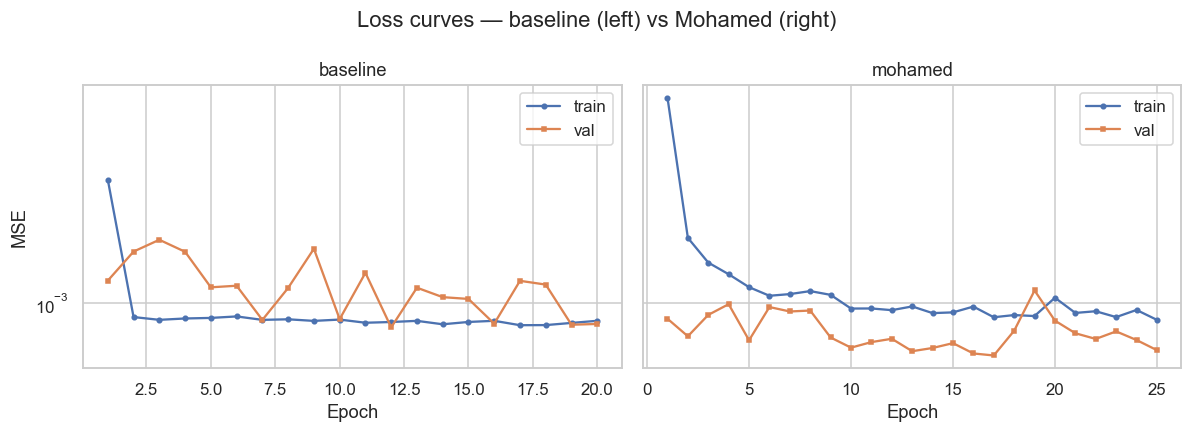

In [5]:
log_base = pd.read_csv(PROJECT_ROOT / 'results' / 'baseline_train_log.csv')
log_moh  = pd.read_csv(PROJECT_ROOT / 'results' / 'mohamed_train_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name, log in [(axes[0], 'baseline', log_base), (axes[1], "mohamed", log_moh)]:
    ax.plot(log['epoch'], log['train_loss'], label='train', marker='o', ms=3)
    ax.plot(log['epoch'], log['val_loss'],   label='val',   marker='s', ms=3)
    ax.set_yscale('log'); ax.set_xlabel('Epoch'); ax.set_title(name)
    ax.legend()
axes[0].set_ylabel('MSE')
fig.suptitle('Loss curves - baseline (left) vs Mohamed (right)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_loss_curves_compare.png', dpi=150)
plt.show()


## 5. Actual vs. predicted (per horizon)

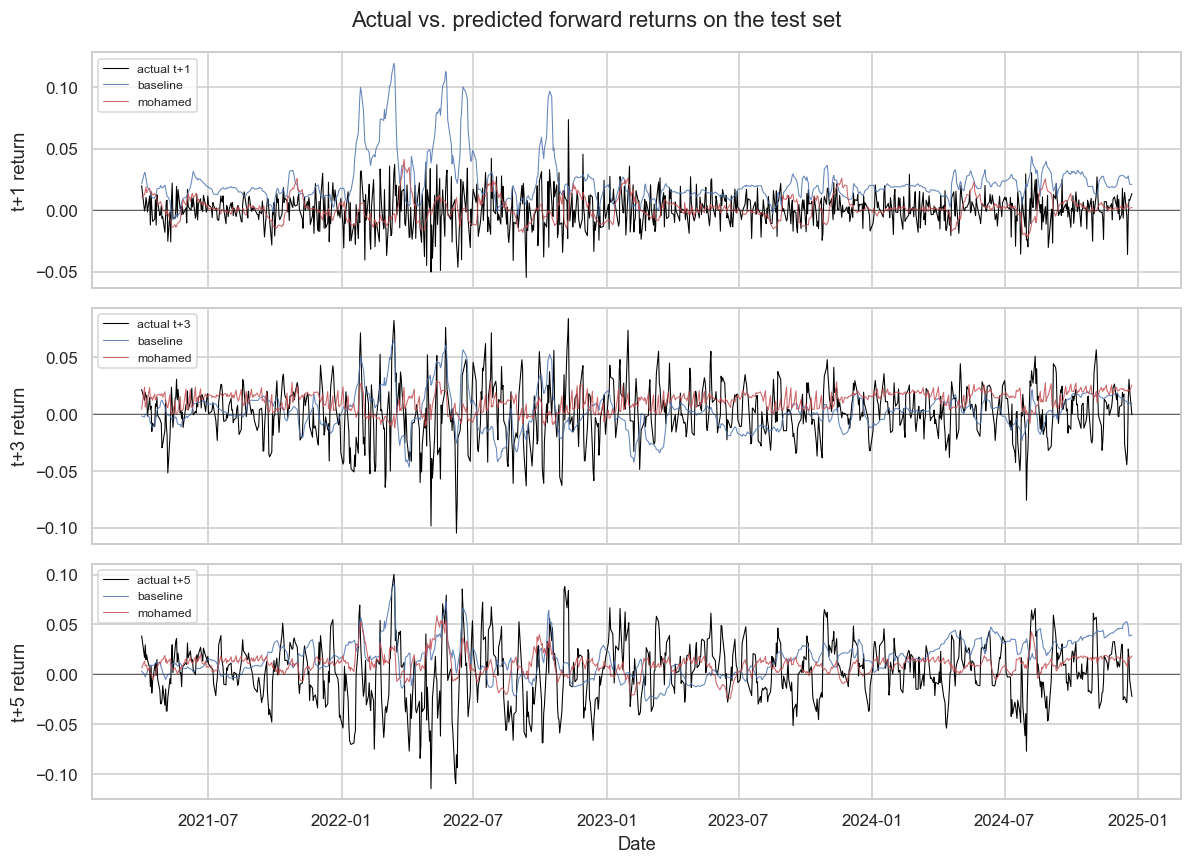

In [6]:
dates_test = ds_base['df']['Date'].iloc[ds_base['idx_test']].values  # baseline & mohamed share dates
# (Confirm by checking that mohamed's dates align - windows are different lengths
#  so mohamed's idx_test may start a few rows later but coverage of the test window matches.)
dates_moh = ds_moh['df']['Date'].iloc[ds_moh['idx_test']].values

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for i, k in enumerate(HORIZONS):
    ax = axes[i]
    ax.plot(dates_test, y_test_base[:, i], color='black', lw=0.7, label=f'actual t+{k}')
    ax.plot(dates_test, yhat_base[:, i], color='C0', lw=0.7, alpha=0.85, label='baseline')
    ax.plot(dates_moh,  yhat_moh[:, i],  color='C3', lw=0.7, alpha=0.85, label='mohamed')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel(f't+{k} return')
    ax.legend(loc='upper left', fontsize=8)
axes[-1].set_xlabel('Date')
fig.suptitle('Actual vs. predicted forward returns on the test set')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_actual_vs_predicted.png', dpi=150)
plt.show()


## 6. Directional-accuracy bar chart

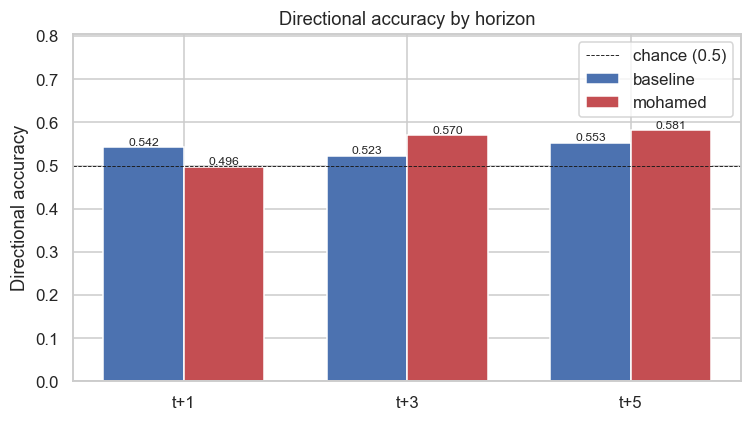

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
horizons_str = [f't+{k}' for k in HORIZONS]
x = np.arange(len(horizons_str)); width = 0.36
b = metrics_base['directional_accuracy'].values
m = metrics_moh['directional_accuracy'].values
ax.bar(x - width/2, b, width, label='baseline', color='C0')
ax.bar(x + width/2, m, width, label='mohamed',  color='C3')
ax.axhline(0.5, color='k', ls='--', lw=0.6, label='chance (0.5)')
ax.set_xticks(x); ax.set_xticklabels(horizons_str)
ax.set_ylabel('Directional accuracy'); ax.set_ylim(0, max(0.7, b.max(), m.max())*1.15)
ax.set_title('Directional accuracy by horizon')
for xi, v in zip(x - width/2, b): ax.text(xi, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
for xi, v in zip(x + width/2, m): ax.text(xi, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_directional_accuracy.png', dpi=150)
plt.show()


## 7. Error distribution

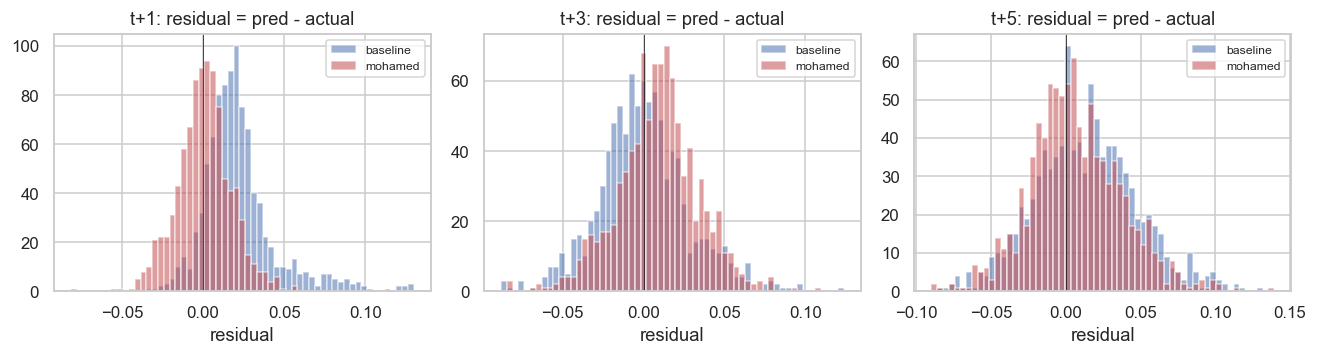

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for i, k in enumerate(HORIZONS):
    ax = axes[i]
    res_b = yhat_base[:, i] - y_test_base[:, i]
    res_m = yhat_moh[:, i]  - y_test_moh[:, i]
    bins = np.linspace(min(res_b.min(), res_m.min()), max(res_b.max(), res_m.max()), 60)
    ax.hist(res_b, bins=bins, alpha=0.55, color='C0', label='baseline')
    ax.hist(res_m, bins=bins, alpha=0.55, color='C3', label='mohamed')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f't+{k}: residual = pred - actual'); ax.set_xlabel('residual'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_residual_histograms.png', dpi=150)
plt.show()


## 8. Top-10 worst predictions (with that day's headlines)

In [9]:
hl = dl.load_headlines()
hl['date_n'] = hl['date'].dt.normalize()
headlines_by_date = hl.groupby('date_n')['headline'].apply(list).to_dict()

dates_base_test = pd.Series(ds_base['df']['Date'].iloc[ds_base['idx_test']].values)
dates_moh_test  = pd.Series(ds_moh['df']['Date'].iloc[ds_moh['idx_test']].values)

worst_b = ev.worst_predictions(dates_base_test, y_test_base, yhat_base,
                               horizon_idx=0, top_k=10,
                               headlines_by_date=headlines_by_date)
worst_m = ev.worst_predictions(dates_moh_test, y_test_moh, yhat_moh,
                               horizon_idx=0, top_k=10,
                               headlines_by_date=headlines_by_date)
worst_b.to_csv(PROJECT_ROOT / 'results' / 'baseline_worst10_t1.csv', index=False)
worst_m.to_csv(PROJECT_ROOT / 'results' / 'mohamed_worst10_t1.csv', index=False)
print('=== Baseline - worst 10 (t+1) ==='); print(worst_b.to_string(index=False))
print(); print('=== Mohamed - worst 10 (t+1) ==='); print(worst_m.to_string(index=False))


=== Baseline - worst 10 (t+1) ===
      date    actual  predicted  abs_error                                                                                                                                                                                                                                                                                                                                                                                                                               headlines
2022-03-11 -0.019205   0.110581   0.129786 The global supply chain’s pandemic recovery is another casualty of Russia’s invasion of Ukraine. | The far right complains after the search engine DuckDuckGo vows to limit Russian propaganda. | The U.S. and the E.U., aiming to punish oligarchs, ban luxury exports to Russia. | China Has Tools to Help Russia’s Economy. None Are Big Enough to Save It. | Boycotts, Not Bombs: Sanctions Are a Go-To Tactic, With Uneven Results
2022-05-23 -0.021262   0.105631 

## 9. Permutation feature importance - Mohamed's model

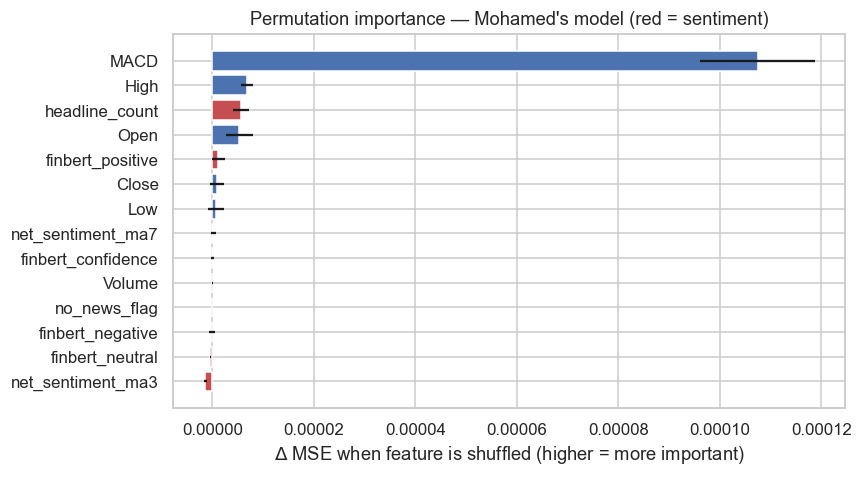

,feature,delta_mse_mean,delta_mse_std
0,MACD,1.074467e-04,1.126643e-05
1,High,6.905524e-06,1.221531e-06
2,headline_count,5.624082e-06,1.537061e-06
3,Open,5.357821e-06,2.730273e-06
4,finbert_positive,1.219897e-06,1.242583e-06
5,Close,9.535579e-07,1.377879e-06
6,Low,7.326792e-07,1.526048e-06
7,net_sentiment_ma7,2.224115e-07,4.603524e-07
8,finbert_confidence,1.199660e-07,2.928472e-07
9,Volume,3.506041e-08,1.161857e-07


In [10]:
def predict_moh(X):
    return tr.predict(mohamed, X.astype(np.float32))

imp = ev.permutation_importance(predict_moh, ds_moh['X_test'], ds_moh['y_test'],
                                ds_moh['feature_names'], n_repeats=3, rng_seed=SEED)
imp.to_csv(PROJECT_ROOT / 'results' / 'mohamed_permutation_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
imp_sorted = imp.sort_values('delta_mse_mean')
colors = ['C3' if f in ALL_FEATURES[6:] else 'C0' for f in imp_sorted['feature']]
ax.barh(imp_sorted['feature'], imp_sorted['delta_mse_mean'],
        xerr=imp_sorted['delta_mse_std'], color=colors)
ax.set_xlabel(r'$\Delta$ MSE when feature is shuffled (higher = more important)')
ax.set_title("Permutation importance - Mohamed's model (red = sentiment)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_permutation_importance.png', dpi=150)
plt.show()
imp


## 10. Verdict

In [11]:
def verdict_row(h):
    b = metrics_base.loc[metrics_base['horizon']==h].iloc[0]
    m = metrics_moh.loc[metrics_moh['horizon']==h].iloc[0]
    return {
        'horizon': h,
        'baseline_mse': b['mse'], 'mohamed_mse': m['mse'],
        'mse_delta_pct': (m['mse']-b['mse'])/b['mse']*100,
        'baseline_diracc': b['directional_accuracy'],
        'mohamed_diracc': m['directional_accuracy'],
        'diracc_delta_pp': (m['directional_accuracy']-b['directional_accuracy'])*100,
    }

verdict = pd.DataFrame([verdict_row(f't+{k}') for k in HORIZONS])
verdict.to_csv(PROJECT_ROOT / 'results' / 'verdict_table.csv', index=False)
verdict


,horizon,baseline_mse,mohamed_mse,mse_delta_pct,baseline_diracc,mohamed_diracc,diracc_delta_pp
0,t+1,0.001014,0.000273,-73.062531,0.542066,0.496273,-4.579340
1,t+3,0.000759,0.000702,-7.572724,0.522897,0.569755,4.685836
2,t+5,0.001335,0.000998,-25.241544,0.552716,0.581470,2.875399


### Findings

The signs of the deltas in the table above tell the story:
- A **negative `mse_delta_pct`** means Mohamed's model lowered MSE relative to
  the baseline at that horizon (sentiment helped).
- A **positive `diracc_delta_pp`** means Mohamed's model improved directional
  accuracy at that horizon by that many percentage points.

Per-horizon interpretation, market-realism caveats, and the answer to
"did sentiment help?" are noted in the `README.md` based on the
realised numbers in `verdict_table.csv`.
